# 7. Sampling and Reconstruction of Signals: Analysis of Aliasing Effects and Proper Signal Reconstruction
# 8. Coding and Decoding Digital Signals
## Variant 6

## Task 3 (Variant 6): Investigate aliasing for a sine wave with f = 30 Hz, sampled at f_s = 40 Hz

Since f_s = 40 Hz < 2·f = 60 Hz (Nyquist rate), aliasing will occur.

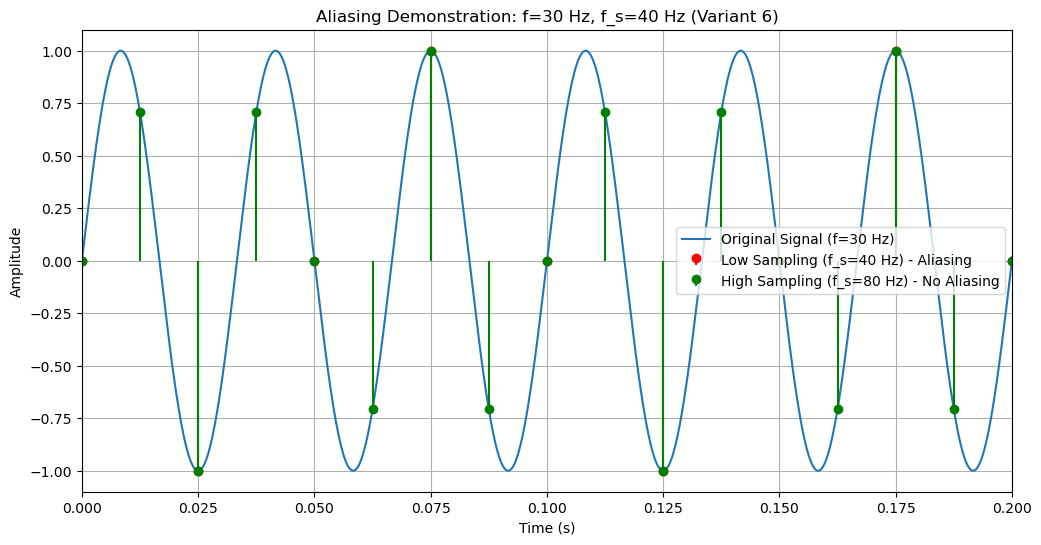

Original frequency: 30 Hz
Sampling frequency: 40 Hz
Nyquist rate: 60 Hz
Aliased frequency: 10 Hz
Aliasing occurs because f_s=40 Hz < 2*f=60 Hz


In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Original signal parameters (Variant 6)
f_signal = 30  # Frequency of the signal (Hz)
t = np.linspace(0, 1, 10000, endpoint=False)  # Time vector (high resolution)
signal = np.sin(2 * np.pi * f_signal * t)  # Original signal

# Sampling parameters
f_sample_low = 40   # Low sampling frequency (Hz) - below Nyquist rate (2*30=60 Hz) -> aliasing
f_sample_high = 80  # High sampling frequency (Hz) - above Nyquist rate -> no aliasing

# Sampling the signal
t_low = np.arange(0, 1, 1 / f_sample_low)
t_high = np.arange(0, 1, 1 / f_sample_high)
samples_low = np.sin(2 * np.pi * f_signal * t_low)
samples_high = np.sin(2 * np.pi * f_signal * t_high)

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(t, signal, label=f'Original Signal (f={f_signal} Hz)')
plt.stem(t_low, samples_low, linefmt='r-', markerfmt='ro', basefmt=" ",
         label=f'Low Sampling (f_s={f_sample_low} Hz) - Aliasing')
plt.stem(t_high, samples_high, linefmt='g-', markerfmt='go', basefmt=" ",
         label=f'High Sampling (f_s={f_sample_high} Hz) - No Aliasing')
plt.title(f'Aliasing Demonstration: f={f_signal} Hz, f_s={f_sample_low} Hz (Variant 6)')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid()
plt.xlim(0, 0.2)  # Zoom in to see aliasing effect clearly
plt.show()

# Calculate aliased frequency
f_aliased = abs(f_signal - f_sample_low)
print(f"Original frequency: {f_signal} Hz")
print(f"Sampling frequency: {f_sample_low} Hz")
print(f"Nyquist rate: {2 * f_signal} Hz")
print(f"Aliased frequency: {f_aliased} Hz")
print(f"Aliasing occurs because f_s={f_sample_low} Hz < 2*f={2*f_signal} Hz")

## Signal Reconstruction (f = 30 Hz, f_s = 80 Hz - proper sampling)

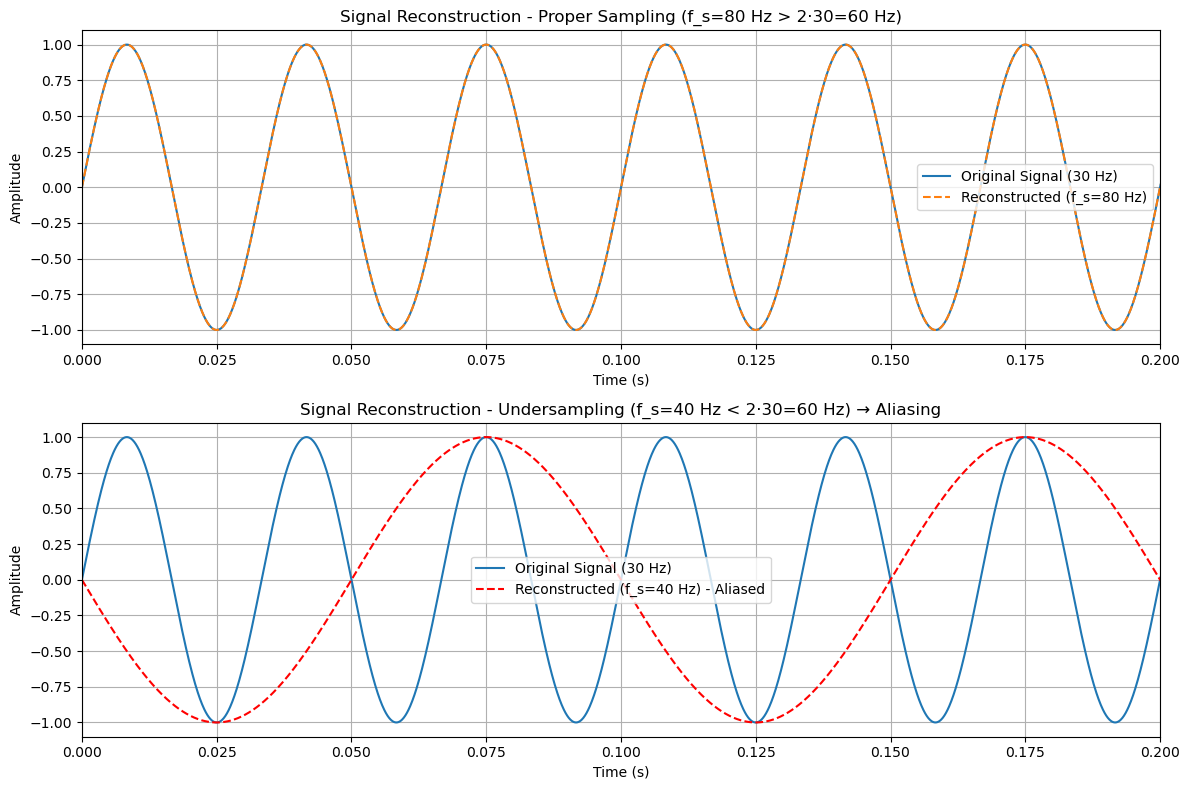

MSE (proper sampling, f_s=80 Hz): 0.000000
MSE (undersampling, f_s=40 Hz):    1.000000


In [14]:
from scipy.signal import resample

# Reconstructing the signal using high sampling rate (f_s=80 Hz, above Nyquist)
num_samples = 10000
reconstructed_high = resample(samples_high, num_samples)

# Reconstructing from low sampling rate (f_s=40 Hz, below Nyquist - aliased)
reconstructed_low = resample(samples_low, num_samples)

# Plotting
plt.figure(figsize=(12, 8))

plt.subplot(2, 1, 1)
plt.plot(t, signal, label='Original Signal (30 Hz)')
plt.plot(t, reconstructed_high, label=f'Reconstructed (f_s={f_sample_high} Hz)', linestyle='--')
plt.title('Signal Reconstruction - Proper Sampling (f_s=80 Hz > 2·30=60 Hz)')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid()
plt.xlim(0, 0.2)

plt.subplot(2, 1, 2)
plt.plot(t, signal, label='Original Signal (30 Hz)')
plt.plot(t, reconstructed_low, label=f'Reconstructed (f_s={f_sample_low} Hz) - Aliased', linestyle='--', color='red')
plt.title('Signal Reconstruction - Undersampling (f_s=40 Hz < 2·30=60 Hz) → Aliasing')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid()
plt.xlim(0, 0.2)

plt.tight_layout()
plt.show()

# Compute reconstruction error
mse_high = np.mean((signal - reconstructed_high) ** 2)
mse_low = np.mean((signal - reconstructed_low) ** 2)
print(f"MSE (proper sampling, f_s={f_sample_high} Hz): {mse_high:.6f}")
print(f"MSE (undersampling, f_s={f_sample_low} Hz):    {mse_low:.6f}")

# Task 4 (Variant 6): Coding and Decoding Digital Signals
## Quantize the signal [0.3, 0.8, 1.2, 1.9, 2.7] to 5 levels and calculate the quantization error.

## Task 4 - Variant 6: Quantization of Signal Samples
Quantize the signal [0.3, 0.8, 1.2, 1.9, 2.7] to 5 levels and calculate the quantization error.

Original Signal:  [0.3 0.8 1.2 1.9 2.7]
Quantized Signal: [0.3  0.78 1.26 1.74 2.7 ]
Quantization Error: [ 0.    0.02 -0.06  0.16  0.  ]
Mean Squared Error (MSE): 0.005920
Max Absolute Error: 0.160000


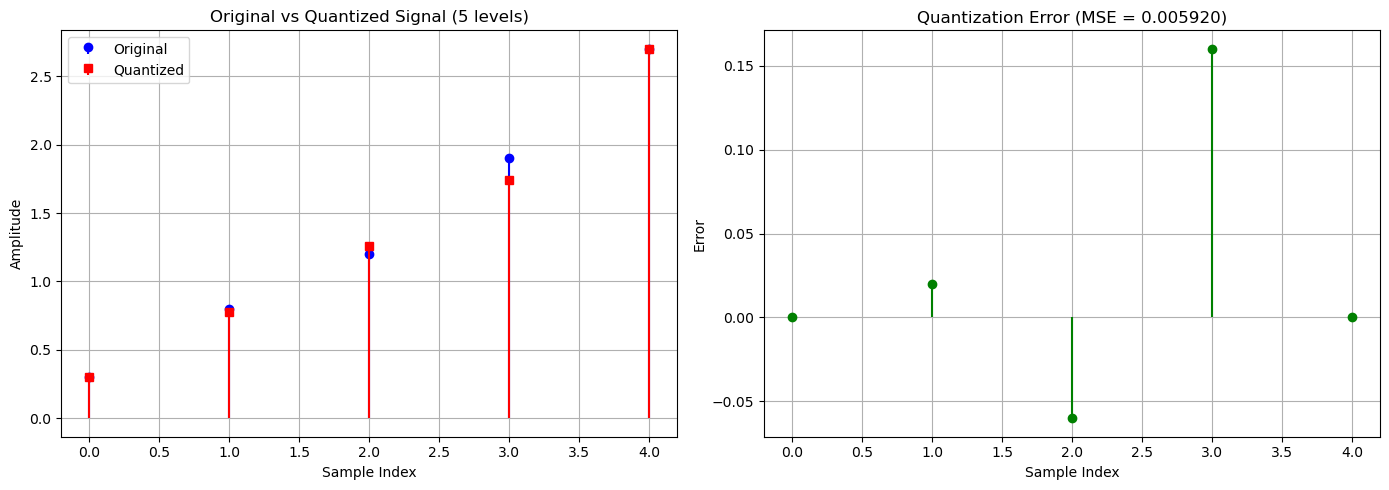

In [15]:
import numpy as np
import matplotlib.pyplot as plt

def quantize(signal, levels):
    min_val, max_val = min(signal), max(signal)
    step_size = (max_val - min_val) / levels
    quantized_signal = np.round((signal - min_val) / step_size) * step_size + min_val
    return quantized_signal

# Variant 6: Quantize [0.3, 0.8, 1.2, 1.9, 2.7] to 5 levels
original_signal = np.array([0.3, 0.8, 1.2, 1.9, 2.7])
levels = 5
quantized_signal = quantize(original_signal, levels=levels)

# Calculate quantization error
quantization_error = original_signal - quantized_signal
mse = np.mean(quantization_error ** 2)

print("Original Signal: ", original_signal)
print("Quantized Signal:", quantized_signal)
print("Quantization Error:", quantization_error)
print(f"Mean Squared Error (MSE): {mse:.6f}")
print(f"Max Absolute Error: {np.max(np.abs(quantization_error)):.6f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot original vs quantized
axes[0].stem(range(len(original_signal)), original_signal, linefmt='b-', markerfmt='bo', basefmt=" ", label='Original')
axes[0].stem(range(len(quantized_signal)), quantized_signal, linefmt='r-', markerfmt='rs', basefmt=" ", label='Quantized')
axes[0].set_title(f'Original vs Quantized Signal ({levels} levels)')
axes[0].set_xlabel('Sample Index')
axes[0].set_ylabel('Amplitude')
axes[0].legend()
axes[0].grid()

# Plot quantization error
axes[1].stem(range(len(quantization_error)), quantization_error, linefmt='g-', markerfmt='go', basefmt=" ")
axes[1].set_title(f'Quantization Error (MSE = {mse:.6f})')
axes[1].set_xlabel('Sample Index')
axes[1].set_ylabel('Error')
axes[1].grid()

plt.tight_layout()
plt.show()